In [1]:
from roboflow import Roboflow
from dotenv import load_dotenv
import os
from pathlib import Path

load_dotenv()
ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")

DATASET_PATH = Path("data") / "cs2"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("jagers-workspace").project("cs2-object-detection-6lnb5")
version = project.version(1)
dataset = version.download("yolov8", location=str(DATASET_PATH))

loading Roboflow workspace...
loading Roboflow project...


In [4]:
from ultralytics import YOLO

model_path = Path("models")

model = YOLO("yolov8s-seg.pt")
model.train(data=DATASET_PATH / "data.yaml", epochs=50, imgsz=640, batch=-1, project=model_path, name="cs2-yolov8s-seg")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+rocm7.1 CUDA:0 (AMD Radeon RX 7700 XT, 12272MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/cs2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cs2-yolov8s-seg, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f70496689e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04104

In [2]:
from ultralytics import YOLO

best_model_path = Path("runs") / "segment" / "models" / "cs2-yolov8s-seg" / "weights" / "best_yolov5.pt"

best_model = YOLO(best_model_path)
# Specify to run it on the test data otherwise it will default to using the validation data
metrics = best_model.val(data=DATASET_PATH / "data.yaml", split="test")

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+rocm7.1 CUDA:0 (AMD Radeon RX 7700 XT, 12272MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,780,374 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3114.3±847.6 MB/s, size: 40.0 KB)
val: Scanning /home/philip/Projects/ML-Assignment-3/data/cs2/test/labels.cache... 112 images, 76 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 112/112 39.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 5.9it/s 1.2s0.2s
                   all        112         53      0.727      0.759      0.763       0.43      0.633      0.666      0.615      0.313
                    CT         20         25      0.717       0.84      0.789      0.475      0.647       0.76      0.673      0.349
                     T         22         28      0.736      0.679      0.738      0.384      0.618      0.571      0.557      0.

In [3]:
print(f"mAP@0.5:0.95  -  {metrics.box.map}")
print(f"mAP@0.5       -  {metrics.box.map50}")
print(f"mAP@0.75      -  {metrics.box.map75}")

print()

print("mAP@0.5:0.95 per class")
for i, class_map in enumerate(metrics.box.maps):
    print(f"{metrics.names[i]:8s}-  {class_map:.4f}")

mAP@0.5:0.95  -  0.42992758799934394
mAP@0.5       -  0.7633553276696676
mAP@0.75      -  0.3702747555055631

mAP@0.5:0.95 per class
CT      -  0.4754
T       -  0.3845



0: 640x640 2 CTs, 7.6ms
1: 640x640 1 T, 7.6ms
Speed: 0.7ms preprocess, 7.6ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


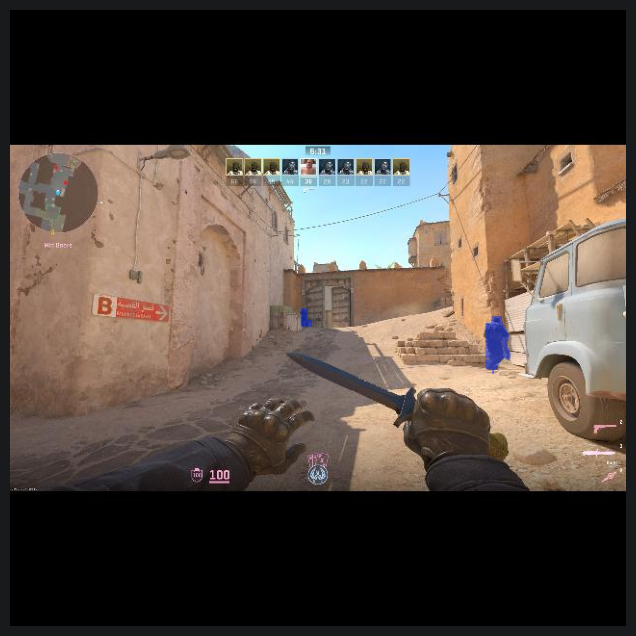

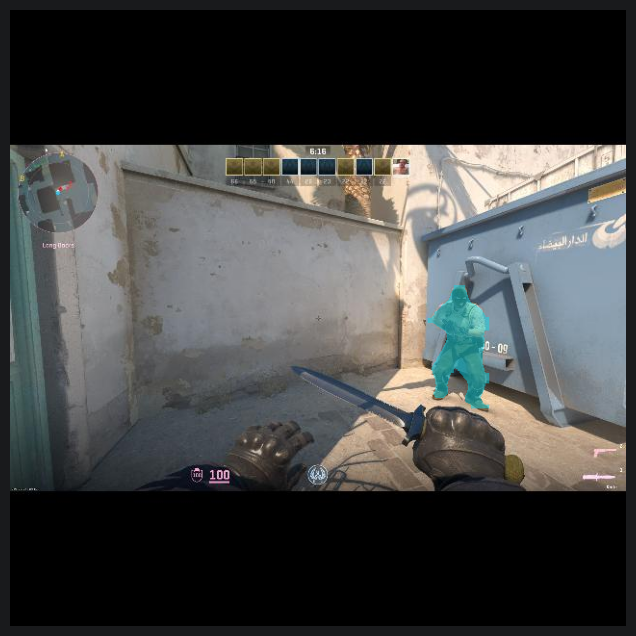

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

test_images = list(Path("data/cs2/test/images").glob("*.*"))[6:8]

results = best_model.predict(test_images, conf=0.5)

for idx, result in enumerate(results):
    img = result.plot(conf=True, boxes=False, masks=True)
    plt.figure(figsize=(12, 8))
    plt.imshow(img[..., ::-1])
    plt.axis("off")
    plt.show()


image 1/1 /home/philip/Projects/ML-Assignment-3/cs2_test_image.jpg: 320x640 1 CT, 2 Ts, 1584.3ms
Speed: 0.9ms preprocess, 1584.3ms inference, 1.0ms postprocess per image at shape (1, 3, 320, 640)


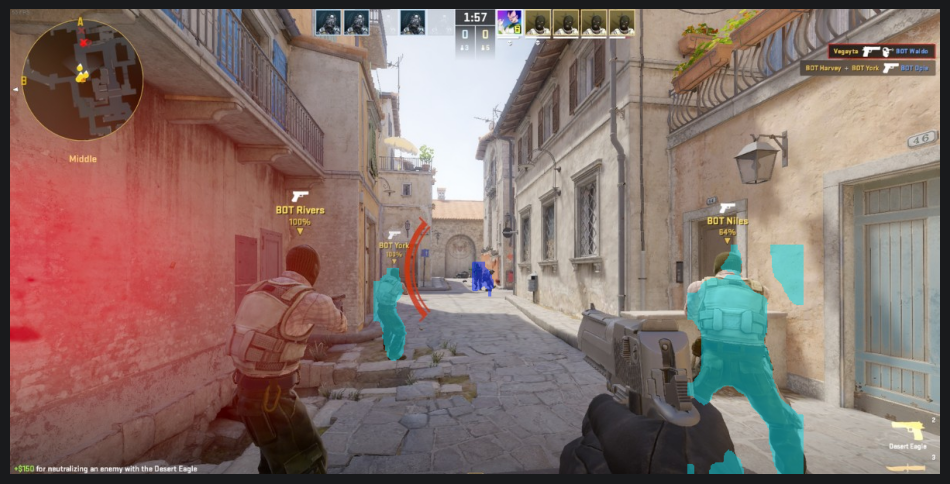

In [6]:
%matplotlib inline
test_images = Path("cs2_test_image.jpg")

results = best_model.predict(test_images, conf=0.5)

img = results[0].plot(conf=True, boxes=False, masks=True)
plt.figure(figsize=(12, 8))
plt.imshow(img[..., ::-1])
plt.axis("off")
plt.show()